In [1]:
%pip install seaborn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import dedent

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from xgboost import XGBClassifier


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Global settings
STATE = 73
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load cancer dataset w/ Features and Target
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

# 0 = Malignant, 1 = Benign
target_names = cancer.target_names

print("Dataset description:")
print(cancer.DESCR)

X.head()
y.head()

# Combining into one dataframe for some reason
df = X.copy()
df["target"] = y
# Assigning target names to the target values instead of 0/1
df["diagnosis"] = df["target"].map(lambda x: target_names[x])


Dataset description:
.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is 

In [3]:
print(dedent("""\n
PROBLEM CONTEXT
===============
The breast cancer Wisconsin dataset has numerical features computed via images of fine needle aspirate (FNA) samples of breast masses.
It originated from the University of Wisconsin.  

The classification problem is to predict whether a tumor is malignant or benign based on the measured cell-nuclei characteristics.
This is an important problem to sovle because accurate early classification supports medical decision-making, reducing unnecessary procedures, and help finding dangerous tumors quickly.
             """))

print(dedent(f"""
DATASET OVERVIEW
================
"Feature matrix shape:", {X.shape}
"Target shape:", {y.shape}
"\nFirst five rows:"
{df.head()}
"\nClass counts:"
{df["diagnosis"].value_counts()}
"\nMissing values per column:"
{df.isnull().sum()
}"\nSummary statistics:"
{X.describe().T}
             """))




PROBLEM CONTEXT
The breast cancer Wisconsin dataset has numerical features computed via images of fine needle aspirate (FNA) samples of breast masses.
It originated from the University of Wisconsin.  

The classification problem is to predict whether a tumor is malignant or benign based on the measured cell-nuclei characteristics.
This is an important problem to sovle because accurate early classification supports medical decision-making, reducing unnecessary procedures, and help finding dangerous tumors quickly.


DATASET OVERVIEW
"Feature matrix shape:", (569, 30)
"Target shape:", (569,)
"
First five rows:"
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4

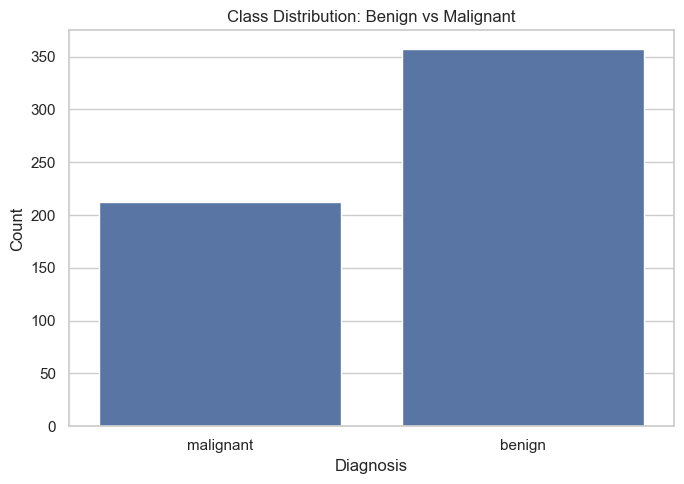

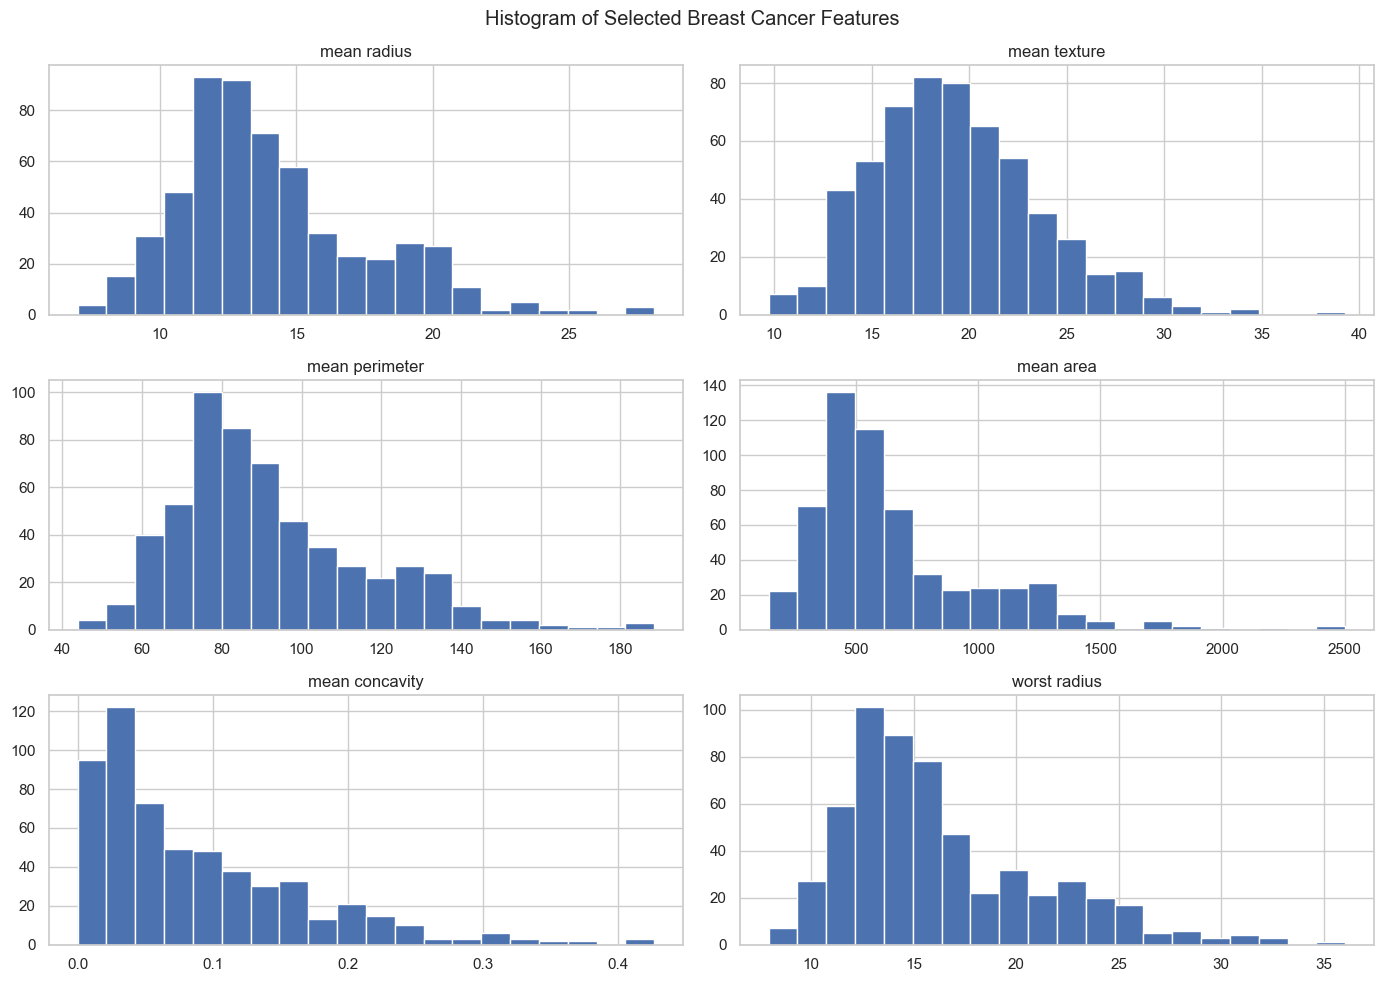

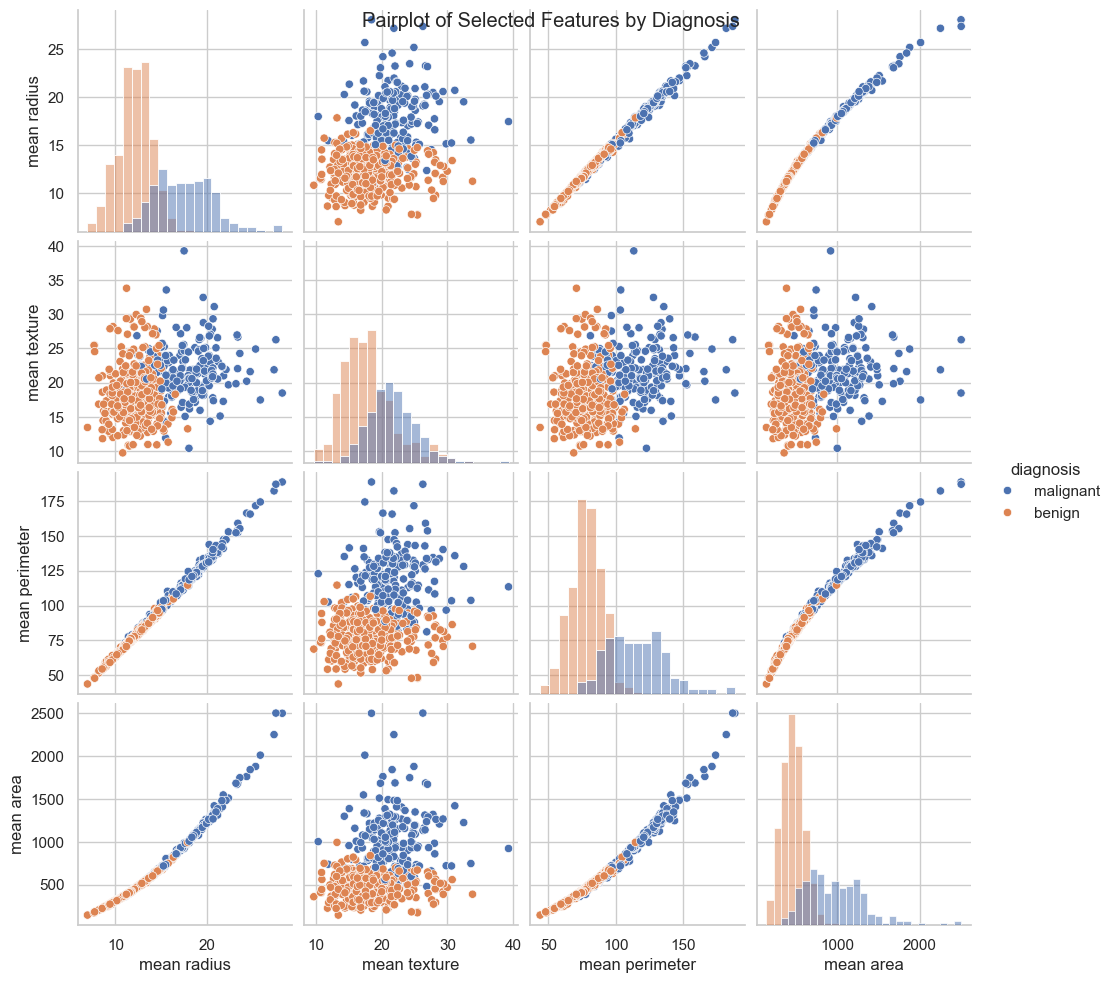

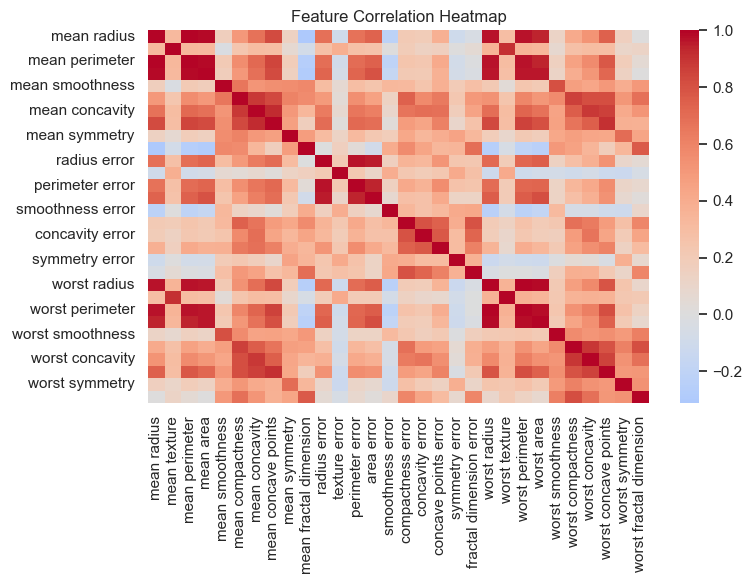


EXPLATORY DATA ANALYSIS
Dataset has 569 observations and 30 numerica predictor variables.
NO missing data.
Target classes are imbalanced, with benign cases more common than malignant ones.
Histograms and pairplots imply multiple features related to tumor size and shape, like radius, perimeter, area, and concavity, 
differ profoundly between the two dignosis groups. 
The correlation heatmap also shows strong multicolinearity among size-related predictors, especially radius, perimeter, and area measurements.
One important modeling idea is that the predictors include overlapping info, which can increase model complexity and the risk of overfitting.
Also, considering class, since even moderate imbalance can affect how evaluation metrics should be interpreted.



In [4]:
# ++++++++++ EDA ++++++++++
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="diagnosis")
plt.title("Class Distribution: Benign vs Malignant")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Histogram stuffz
chosen_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity",
    "worst radius"
]

df[chosen_features].hist(bins=20, figsize=(14, 10))
plt.suptitle("Histogram of Selected Breast Cancer Features")
plt.tight_layout()
plt.show()

# Pairplot for subsets
pairplot_feats = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "diagnosis"
]

sns.pairplot(df[pairplot_feats], hue="diagnosis", diag_kind="hist")
plt.suptitle("Pairplot of Selected Features by Diagnosis")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

print(dedent(f"""
EXPLATORY DATA ANALYSIS
======================
Dataset has {X.shape[0]} observations and {X.shape[1]} numerica predictor variables.
NO missing data.
Target classes are imbalanced, with benign cases more common than malignant ones.
Histograms and pairplots imply multiple features related to tumor size and shape, like radius, perimeter, area, and concavity, 
differ profoundly between the two dignosis groups. 
The correlation heatmap also shows strong multicolinearity among size-related predictors, especially radius, perimeter, and area measurements.
One important modeling idea is that the predictors include overlapping info, which can increase model complexity and the risk of overfitting.
Also, considering class, since even moderate imbalance can affect how evaluation metrics should be interpreted.
             """))


In [5]:
# Training/Testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    # 80/20 rule
    test_size=.2,
    random_state=STATE,
    stratify=y
)

print("TRAIN/TEST SPLIT")
print(dedent(
f"""
X_train shape: {X_train.shape}
X_test shape: {X_test.shape}
Training Class Proportions:
{y_train.value_counts(normalize=True)}
Test Class Proportions:
{y_test.value_counts(normalize=True)}
"""
))

print(dedent(f"""
ROC-AUC measures how well the model differentiates between benign cases as the positive class.
             """))


TRAIN/TEST SPLIT

X_train shape: (455, 30)
X_test shape: (114, 30)
Training Class Proportions:
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64
Test Class Proportions:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


ROC-AUC measures how well the model differentiates between benign cases as the positive class.




HYPERPARAMETER SELECTION
1) max_depth:
COntrols the maximum depth of each tree in the XGBoost, useful since the dataset has 569 numerical features and the EDA showed multicolinearity among radius, perimeter, and area measurements.

2) learning_rate (step size parameter):
Controls how much each new  tree contributes to the overall boosted model.
Since the dataset is pretty small, this is useful for the learning rate generally makes learning more gradual and improves generalization.


INITIAL MODEL PERFORMANCE
Initial accuracy: 0.982
Initial ROC-AUC: 0.998

Classification Report
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114




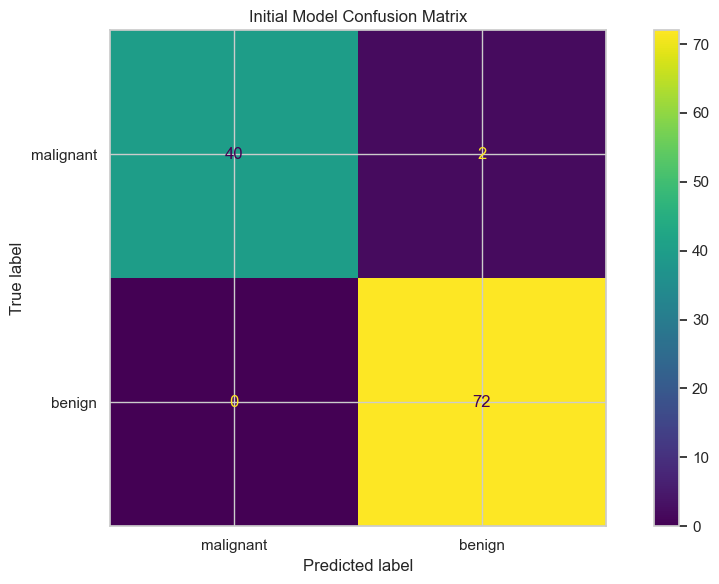

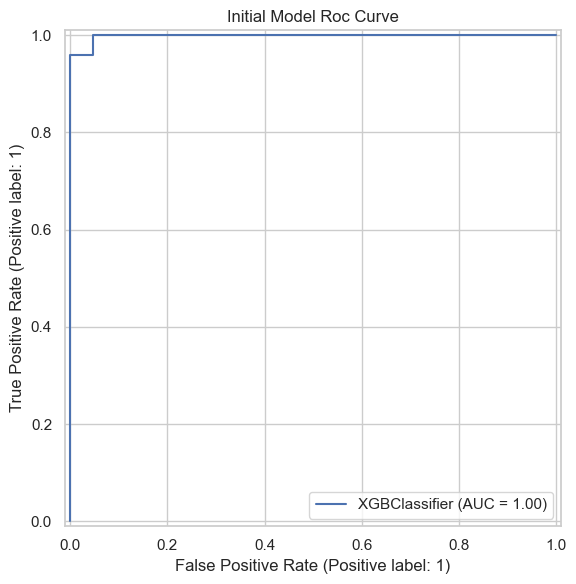


INITIAL MODEL TRAININIG
The initial XGBoost model was trained on the training set using the chosen hyperparameter values.
I selected accuracy and ROC-AUC as the two evaluation metrics, since accuracy provides a simple metric for overall classification, while ROC-AUC evaluates how well the model separates the classes across possible decision thresholds.
Initial model achieved an accuracy of 0.982 and a ROC-AUC
             score of 0.998.

Fitting 5 folds for each of 20 candidates, totalling 100 fits

HYPERPARAMETER TUNING
Results:
Best parameters are {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
Best Cross-validation:
0.995
Tuned Accuracy: 0.982
Tuned ROC-AUC: 0.999

Tuned Model Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg 

In [6]:
# HYperparameter selection
print(dedent(f"""
HYPERPARAMETER SELECTION
========================
1) max_depth:
COntrols the maximum depth of each tree in the XGBoost, useful since the dataset has {X.shape[0]} numerical features and the EDA showed multicolinearity among radius, perimeter, and area measurements.

2) learning_rate (step size parameter):
Controls how much each new  tree contributes to the overall boosted model.
Since the dataset is pretty small, this is useful for the learning rate generally makes learning more gradual and improves generalization.
             """))

# Initial model trainging
initial_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.10,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    importance_type="gain",
    random_state=STATE
)

initial_model.fit(X_train, y_train)

y_pred_initial = initial_model.predict(X_test)
y_prob_initial = initial_model.predict_proba(X_test)[:, 1]

initial_accuracy = accuracy_score(y_test, y_pred_initial)
initial_auc = roc_auc_score(y_test, y_prob_initial)

print(dedent(f"""
INITIAL MODEL PERFORMANCE
=========================
Initial accuracy: {initial_accuracy:.3f}
Initial ROC-AUC: {initial_auc:.3f}

Classification Report
{classification_report(y_test, y_pred_initial, target_names=target_names)}
             """))

cm_initial = confusion_matrix(y_test, y_pred_initial)
disp_initial = ConfusionMatrixDisplay(
    confusion_matrix=cm_initial,
    display_labels=target_names
)

disp_initial.plot()
plt.title("Initial Model Confusion Matrix")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(initial_model, X_test, y_test)
plt.title("Initial Model Roc Curve")
plt.tight_layout()
plt.show()

print(dedent(f"""
INITIAL MODEL TRAININIG
======================
The initial XGBoost model was trained on the training set using the chosen hyperparameter values.
I selected accuracy and ROC-AUC as the two evaluation metrics, since accuracy provides a simple metric for overall classification, while ROC-AUC evaluates how well the model separates the classes across possible decision thresholds.
Initial model achieved an accuracy of {initial_accuracy:.3f} and a ROC-AUC
             score of {initial_auc:.3f}.
             """))

# HYperparameter Tuning
param_dist = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.10, 0.20, 0.30],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    importance_type="gain",
    random_state=STATE
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=STATE
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print(dedent(f"""
HYPERPARAMETER TUNING
=====================
Results:
Best parameters are {random_search.best_params_}
Best Cross-validation:
{random_search.best_score_:.3f}
Tuned Accuracy: {tuned_accuracy:.3f}
Tuned ROC-AUC: {tuned_auc:.3f}

Tuned Model Classification Report:
{classification_report(y_test, y_pred_tuned, target_names=target_names)}
             """))



Feature Coefficients per Class:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -1.088945          1.024208          -1.799056         -1.686228   
1           0.536337         -0.360487          -0.204074         -0.807957   
2           0.552608         -0.663721           2.003130          2.494185   

        class  
0      setosa  
1  versicolor  
2   virginica  


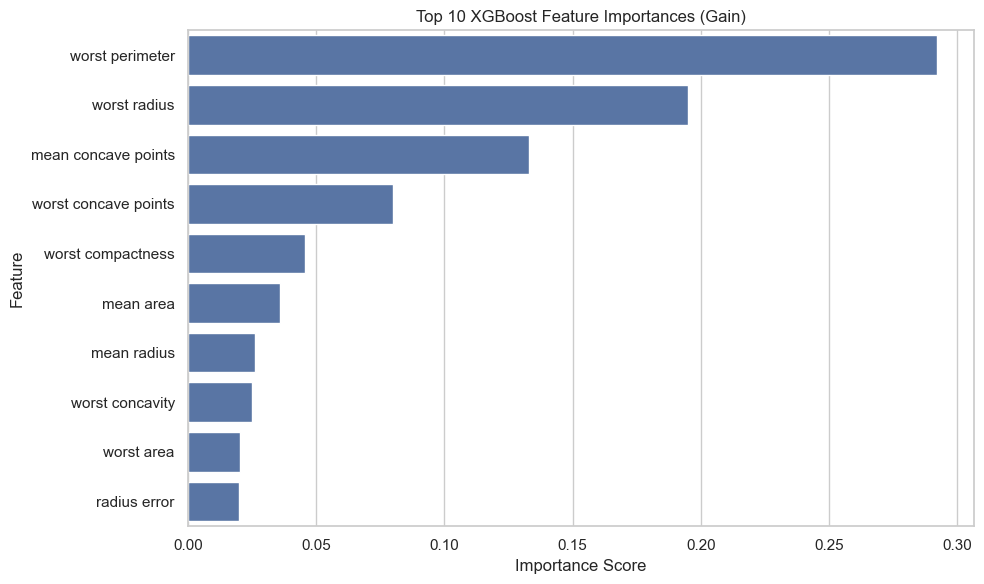


FEATURE IMPORTANCE AND INTERPRETATION
worst perimeter         0.291860
worst radius            0.194862
mean concave points     0.132959
worst concave points    0.079975
worst compactness       0.045646
mean area               0.035989
mean radius             0.026190
worst concavity         0.024839
worst area              0.020338
radius error            0.019703
dtype: float32

             The final tuned XGBoost model ranked worst perimeter
             (0.292) and worst radius (0.195),
             and mean concave points (0.133) 
as its three most important predictors. These were followed by worst concave points
(0.0800) and worst compactness (0.0456). This suggests
that the model relied most strongly on measurements related to tumor size,
boundary irregularity, and structural complexity, which is medically plausible
because malignant tumors tend to show more irregular and invasive cellular
patterns than benign tumors. The importance values here are gain-based
XGBoost importanc

In [7]:
# Feature IMportance and INterpretation
# Because importance_type="gain" was specified, these importances
# reflect gain-based feature importance.
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_n = 10
top_importances = importances.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances.values, y=top_importances.index)
plt.title("Top 10 XGBoost Feature Importances (Gain)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

top_features = list(top_importances.index[:5])
top_scores = list(top_importances.values[:5])

print(dedent(f"""
FEATURE IMPORTANCE AND INTERPRETATION
====================================
{top_importances}

             The final tuned XGBoost model ranked {top_features[0]}
             ({top_scores[0]:.3f}) and {top_features[1]} ({top_scores[1]:.3f}),
             and {top_features[2]} ({top_scores[2]:.3f}) 
as its three most important predictors. These were followed by {top_features[3]}
({top_scores[3]:.4f}) and {top_features[4]} ({top_scores[4]:.4f}). This suggests
that the model relied most strongly on measurements related to tumor size,
boundary irregularity, and structural complexity, which is medically plausible
because malignant tumors tend to show more irregular and invasive cellular
patterns than benign tumors. The importance values here are gain-based
XGBoost importances, so they reflect how much each feature improved the model's
splits on average rather than implying causation. In a medical context, this
matters because it helps identify which observed tumor characteristics were most
informative for the classification decision.
             """))

# Summary
summary_df = pd.DataFrame({
    "Model": ["Initial XGBoost", "Tuned XGBoost"],
    "Accuracy": [initial_accuracy, tuned_accuracy],
    "ROC-AUC": [initial_auc, tuned_auc]
})

print(dedent(f"""
MODEL SUMMARY
=============
{summary_df}
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
AI Disclosure:
Claude was used to outsource the tedium of print statements, some visualization portions, but mostly to elaborate on the concepts learned for the sake of implementing the code myself.
             """))
